In [ ]:
!pip install numpy==2.0.2
!pip install pandas==2.2.2
!pip install tensorflow_cpu==2.18.0
!pip install matplotlib==3.9.2

In [ ]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [ ]:
!pip install --upgrade ml_dtypes

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.datasets import mnist

In [ ]:
import tensorflow as tf

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Add a channel dimension (28, 28) -> (28, 28, 1) before resizing
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')

X_train = X_train / 255
X_test = X_test / 255

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1]

**CNNs Architecture**

Layers in order:


*   Convoltional: This layer uses filters, which dimensions we have defined. The filters automatically learn the features of the image and update its own weights
*   MaxPooling: This layer takes in each of the max values of the filter to only emphasize those specific features that the filters have understood

We repeat this multiple times to get a better understanding of the image
*   Flatten: We need to now flatten the image in a one dimensional vector so that we can feed it to the fully connected layer
*   Fully connected layers: These layers now intake the heirarchical features that have been defined and grouped by the convolution and MaxPooling layers and outputs a classification probabilty.







In [ ]:
def convolutional_model():
  model = Sequential()
  model.add(Input(shape= (28, 28, 1))) # Updated input shape to match resized images
  model.add(Conv2D(32, (5,5), activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
  model.add(Conv2D(64, (2,2), activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2)))
  model.add(Conv2D(128, (2,2), activation='relu'))
  model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

  model.add(Flatten())
  model.add(Dense(100, activation='relu'))
  model.add(Dense(num_classes, activation='softmax'))

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

  return model

In [ ]:
# build the model
model = convolutional_model()

# fit the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: {} \n Error: {}".format(scores[1], 100-scores[1]*100))

Epoch 1/10
300/300 - 48s - 161ms/step - accuracy: 0.9027 - loss: 0.3358 - val_accuracy: 0.9756 - val_loss: 0.0748
Epoch 2/10
300/300 - 82s - 272ms/step - accuracy: 0.9785 - loss: 0.0708 - val_accuracy: 0.9836 - val_loss: 0.0536
Epoch 3/10
300/300 - 43s - 143ms/step - accuracy: 0.9851 - loss: 0.0494 - val_accuracy: 0.9864 - val_loss: 0.0391
Epoch 4/10
300/300 - 83s - 276ms/step - accuracy: 0.9882 - loss: 0.0391 - val_accuracy: 0.9871 - val_loss: 0.0392
Epoch 5/10
300/300 - 43s - 143ms/step - accuracy: 0.9900 - loss: 0.0324 - val_accuracy: 0.9898 - val_loss: 0.0304
Epoch 6/10
300/300 - 84s - 279ms/step - accuracy: 0.9912 - loss: 0.0280 - val_accuracy: 0.9912 - val_loss: 0.0256
Epoch 7/10
300/300 - 44s - 146ms/step - accuracy: 0.9927 - loss: 0.0233 - val_accuracy: 0.9898 - val_loss: 0.0289
Epoch 8/10
300/300 - 83s - 277ms/step - accuracy: 0.9936 - loss: 0.0204 - val_accuracy: 0.9874 - val_loss: 0.0390
Epoch 9/10
300/300 - 44s - 148ms/step - accuracy: 0.9947 - loss: 0.0169 - val_accuracy: 

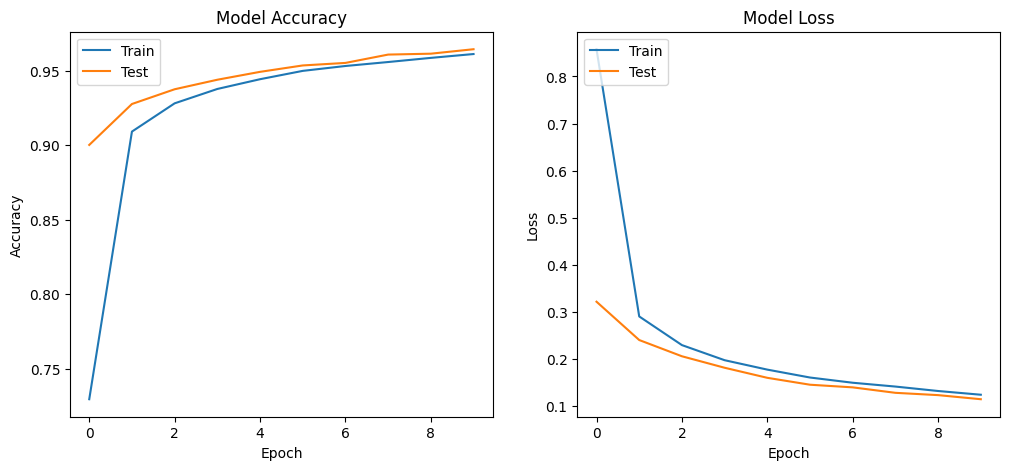

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()